In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sksurv.util import Surv
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import (concordance_index_censored,
                            cumulative_dynamic_auc,
                            integrated_brier_score)
from sksurv.nonparametric import kaplan_meier_estimator

RANDOM_STATE = 42


In [2]:
# import data from github

URL = ("https://raw.githubusercontent.com/autonlab/auton-survival/master/auton_survival/datasets/support2.csv")
df = pd.read_csv(URL)

print(df.shape)

print(df.columns)

(9105, 48)
Index(['sno', 'age', 'death', 'sex', 'hospdead', 'slos', 'd.time', 'dzgroup',
       'dzclass', 'num.co', 'edu', 'income', 'scoma', 'charges', 'totcst',
       'totmcst', 'avtisst', 'race', 'sps', 'aps', 'surv2m', 'surv6m', 'hday',
       'diabetes', 'dementia', 'ca', 'prg2m', 'prg6m', 'dnr', 'dnrday',
       'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea',
       'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls', 'sfdm2',
       'adlsc'],
      dtype='str')


In [3]:
df.head(10)

,sno,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0000
1,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0000
2,3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.0000
3,4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.0000
4,5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.0000
5,6,93.01599,1,male,1,4,4,Coma,Coma,1,...,0.699951,140.0,7.659180,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0000
6,7,62.37097,1,male,0,9,659,CHF,COPD/CHF/Cirrhosis,1,...,1.599854,132.0,7.479492,NaN,NaN,NaN,0.0,1.0,no(M2 and SIP pres),1.0000
7,8,86.83899,1,male,0,7,142,CHF,COPD/CHF/Cirrhosis,3,...,2.000000,139.0,7.509766,NaN,NaN,NaN,NaN,0.0,NaN,0.0000
8,9,85.65594,1,male,0,12,63,Lung Cancer,Cancer,2,...,1.000000,143.0,7.449219,NaN,NaN,NaN,NaN,7.0,NaN,7.0000
9,10,42.25897,1,female,0,8,370,Colon Cancer,Cancer,0,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.4948


In [4]:
print(df["death"].value_counts().to_dict())

# 1 is death and 0 is censored

{1: 6201, 0: 2904}


In [5]:
num = ["age","num.co","scoma","meanbp","wblc","hrt","resp","temp",   # числовые признаки:
       "pafi","alb","bili","crea","sod","ph","glucose","bun"]          # возраст, коморбидности, кома-скор, физиология, лабы
cat = ["sex","dzgroup","race"]

X = df[num + cat].copy()

y = Surv.from_arrays(event=df["death"].astype(bool).values,
                     time=df["d.time"].values)
print("Features:", X.shape[1], y)

Features: 19 [(False, 2029.) ( True,    4.) ( True,   47.) ... (False,  346.)
 ( True,    7.) ( True,  198.)]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["death"])

print("Train / Test:", X_train.shape[0], "/", X_test.shape[0])

Train / Test: 6828 / 2277


In [7]:
# Preprocessing

pre = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler())]), num),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat)           
])


X_train_t = pre.fit_transform(X_train)
X_test_t = pre.transform(X_test)

X_train_t = X_train_t.toarray() if hasattr(X_train_t, "toarray") else X_train_t
X_test_t = X_test_t.toarray() if hasattr(X_test_t, "toarray") else X_test_t

print("Shape after preprocessing:", X_train_t.shape, X_test_t.shape)


Shape after preprocessing: (6828, 31) (2277, 31)


In [8]:
# Models
# 1. CoxPHSurvivalAnalysis. "Linear Regression" of Survival. It learns how each feature changes risk

cox = CoxPHSurvivalAnalysis(alpha=0.1)
cox.fit(X_train_t, y_train)


# 2. Random Survival Forest (RSF). It captures non-linear effects and interactions that Cox misses

rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state= RANDOM_STATE)
rsf.fit(X_train_t, y_train)

print("Learning is done.")

Learning is done.


In [9]:
# Checking by C_index
# C_index gives us the answer for the question: " If I pick 2 patients from the test set, how often does the model correctly say who will die first"

for name, m in [("cox", cox), ("rsf", rsf)]:
    risk = m.predict(X_test_t)
    c = concordance_index_censored(y_test["event"],
                                   y_test["time"],
                                   risk)[0]
    print(f"{name:} C_index: {c:.3f}")

cox C_index: 0.678
rsf C_index: 0.680


In [10]:
# Checking by IBS and AUC

event_times = y_test["time"][y_test["event"]]
low, high = np.percentile(event_times, [10, 90])
grid = np.linspace(low, high, 30)


for name, m in [("cox", cox), ("RSF", rsf)]:
    surv_fns = m.predict_survival_function(X_test_t)
    S = np.vstack([[fn(t) for t in grid] for fn in surv_fns])
    ibs = integrated_brier_score(y_train, y_test, S, grid)
    auc, mean_auc = cumulative_dynamic_auc(y_train, y_test, m.predict(X_test_t), grid)
    print(f"{name} IBS: {ibs:.3f} | mean Time-AUC: {mean_auc:.3f}")

cox IBS: 0.199 | mean Time-AUC: 0.729
RSF IBS: 0.194 | mean Time-AUC: 0.729


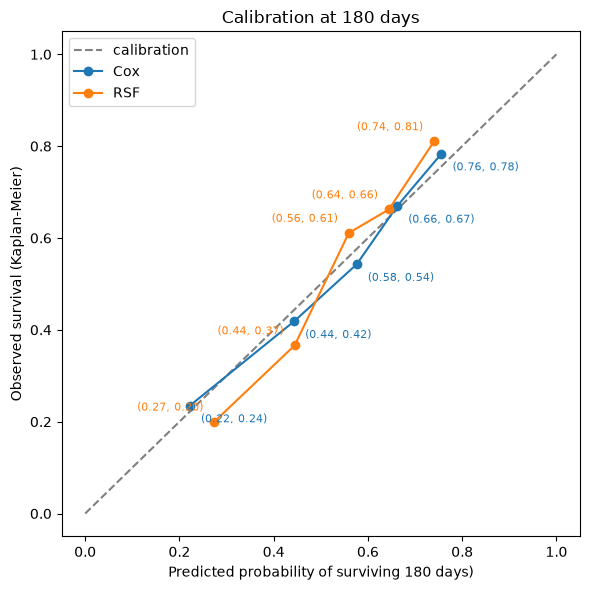

In [11]:
# Calibration

t0 = 180

def surv_at(model, X, t0):
    return np.array([fn(t0) for fn in model.predict_survival_function(X)])

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "--", color= "gray", label= "calibration")

offsets = {"Cox": (8, -12), "RSF": (-8, 8)}

for name, m in [("Cox", cox), ("RSF", rsf)]:
    p = surv_at(m, X_test_t, t0)
    edges = np.quantile(p, np.linspace(0, 1, 6))
    edges[0] -= 1e-9; edges[-1] += 1e-9
    b = np.digitize(p, edges) - 1
    xs, ys = [], []
    for g in range(5):
        mask = b == g
        if mask.sum() < 10:
            continue
        tt, ss = kaplan_meier_estimator(y_test["event"][mask], y_test["time"][mask])
        obs = np.interp(t0, tt, ss)
        xs.append(p[mask].mean())
        ys.append(obs)
    line, = plt.plot(xs, ys, "o-", label=name)
    for x, y in zip(xs, ys):                    
        plt.annotate(f"({x:.2f}, {y:.2f})",     
                        (x, y),                   
                        textcoords="offset points",
                        xytext=offsets[name],      
                        ha="left" if name == "Cox" else "right",
                        fontsize=8,
                        color=line.get_color())   

plt.xlabel(f"Predicted probability of surviving {int(t0)} days)")          
plt.ylabel("Observed survival (Kaplan-Meier)")                              
plt.title(f"Calibration at {int(t0)} days")                        
plt.legend() 
plt.tight_layout() 
plt.show()  

### Outcome: model choice

| Metric | Cox | RSF | Better |
|---|---|---|---|
| C-index ↑ | 0.678 | 0.680 | ≈ equal |
| Mean time-AUC ↑ | 0.729 | 0.729 | equal |
| IBS ↓ | 0.199 | 0.194 | RSF, slightly |
| Calibration at 180 days | close to the diagonal (error ≤ 0.03) | off by up to 0.08 | **Cox** |

**Ranking:** both models rank patients by risk equally well. The differences in C-index and time-AUC are within random noise.

**Probabilities:** RSF has a slightly lower IBS, but IBS is averaged over all time points and all patients. The calibration plot at 180 days shows where the errors are:
- **Cox** stays close to the diagonal in all five risk groups, so its predicted survival probabilities match observed survival.
- **RSF** compresses its predictions towards the middle. It is too optimistic for high-risk patients (predicts 27% survival, observed 20%) and too pessimistic for low-risk patients (predicts 74%, observed 81%). This is typical for random forests, because averaging many trees pulls predictions towards the mean.

**Decision: Cox.** It performs as well as RSF on ranking, gives more reliable survival probabilities for the sickest patients, and is easier to explain through hazard ratios.

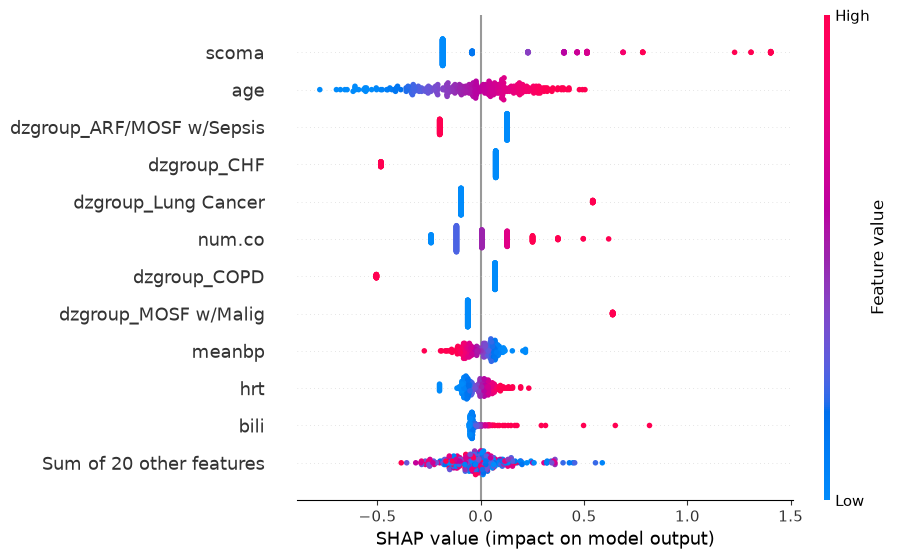

In [ ]:
# Let's use SHAP in order to understand how models use features

# SHAP for COX

import shap

feature_names = [n.split("__", 1)[1] for n in pre.get_feature_names_out()]

background = shap.sample(X_train_t, 100, random_state = RANDOM_STATE)
X_explain = X_test_t[:300]

cox_explainer = shap.Explainer(cox.predict, background, feature_names=feature_names)
shap_cox = cox_explainer(X_explain)

shap.plots.beeswarm(shap_cox, max_display=12)


PermutationExplainer explainer: 101it [10:35:48, 393.29s/it]                             


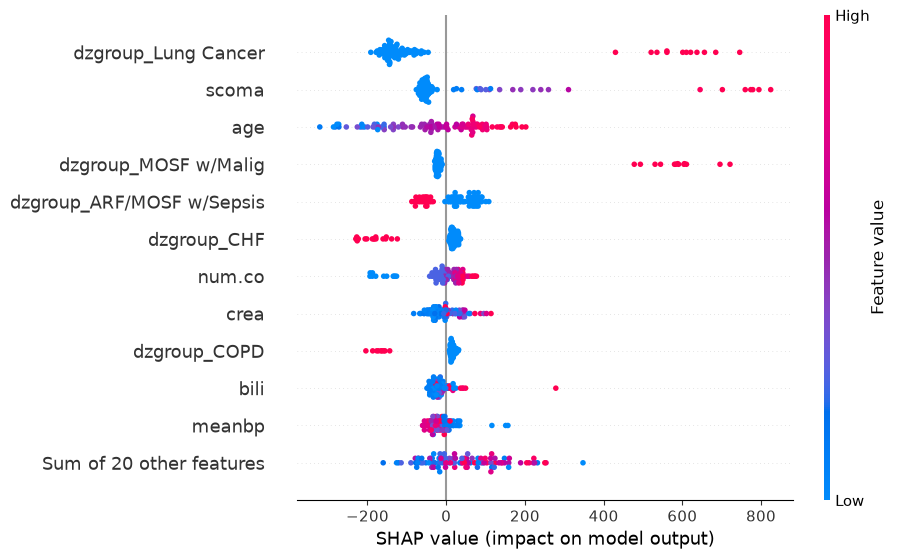

In [15]:
# SHAP for RSF

rsf_explainer = shap.Explainer(rsf.predict,
                               shap.sample(X_train_t, 30, random_state=RANDOM_STATE),
                               feature_names=feature_names)
shap_rsf = rsf_explainer(X_test_t[:100])

shap.plots.beeswarm(shap_rsf, max_display=12)